In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import features as ft
import re
import pyarrow

In [2]:
features_df = pd.read_parquet(r"..\data\features.parquet", engine="pyarrow")

# Chunk de una hora

In [3]:
hours = 1
# clustering_data = features_raw_df.copy()
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_movil_mean'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_movil_mean'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_movil_mean'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()

features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

In [4]:
features_df_run = features_df[features_df['timestamp']<"2022-02-01"]

features_df_run

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean
0,2022-01-01 00:05:00,7.074324,0.633977,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,7.020175,0.632777,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,7.011306,0.751629,None,7175.473832,0.032564,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,7.010472,0.750180,None,7186.277967,0.065660,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,6.986411,0.732571,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
8892,2022-01-31 23:35:00,8.830721,2.334161,None,1668.982751,0.629002,8.471704,1.573340,0.347591,2194.681709
8893,2022-01-31 23:40:00,8.817154,2.361190,None,1705.372009,0.451853,8.512201,1.760099,0.385613,2178.716875
8894,2022-01-31 23:45:00,8.051987,0.780485,None,2927.230991,0.083474,8.474237,1.714692,0.360933,2273.282381
8895,2022-01-31 23:50:00,7.990021,0.815191,None,3100.668472,0.158434,8.432990,1.659252,0.330689,2379.334500


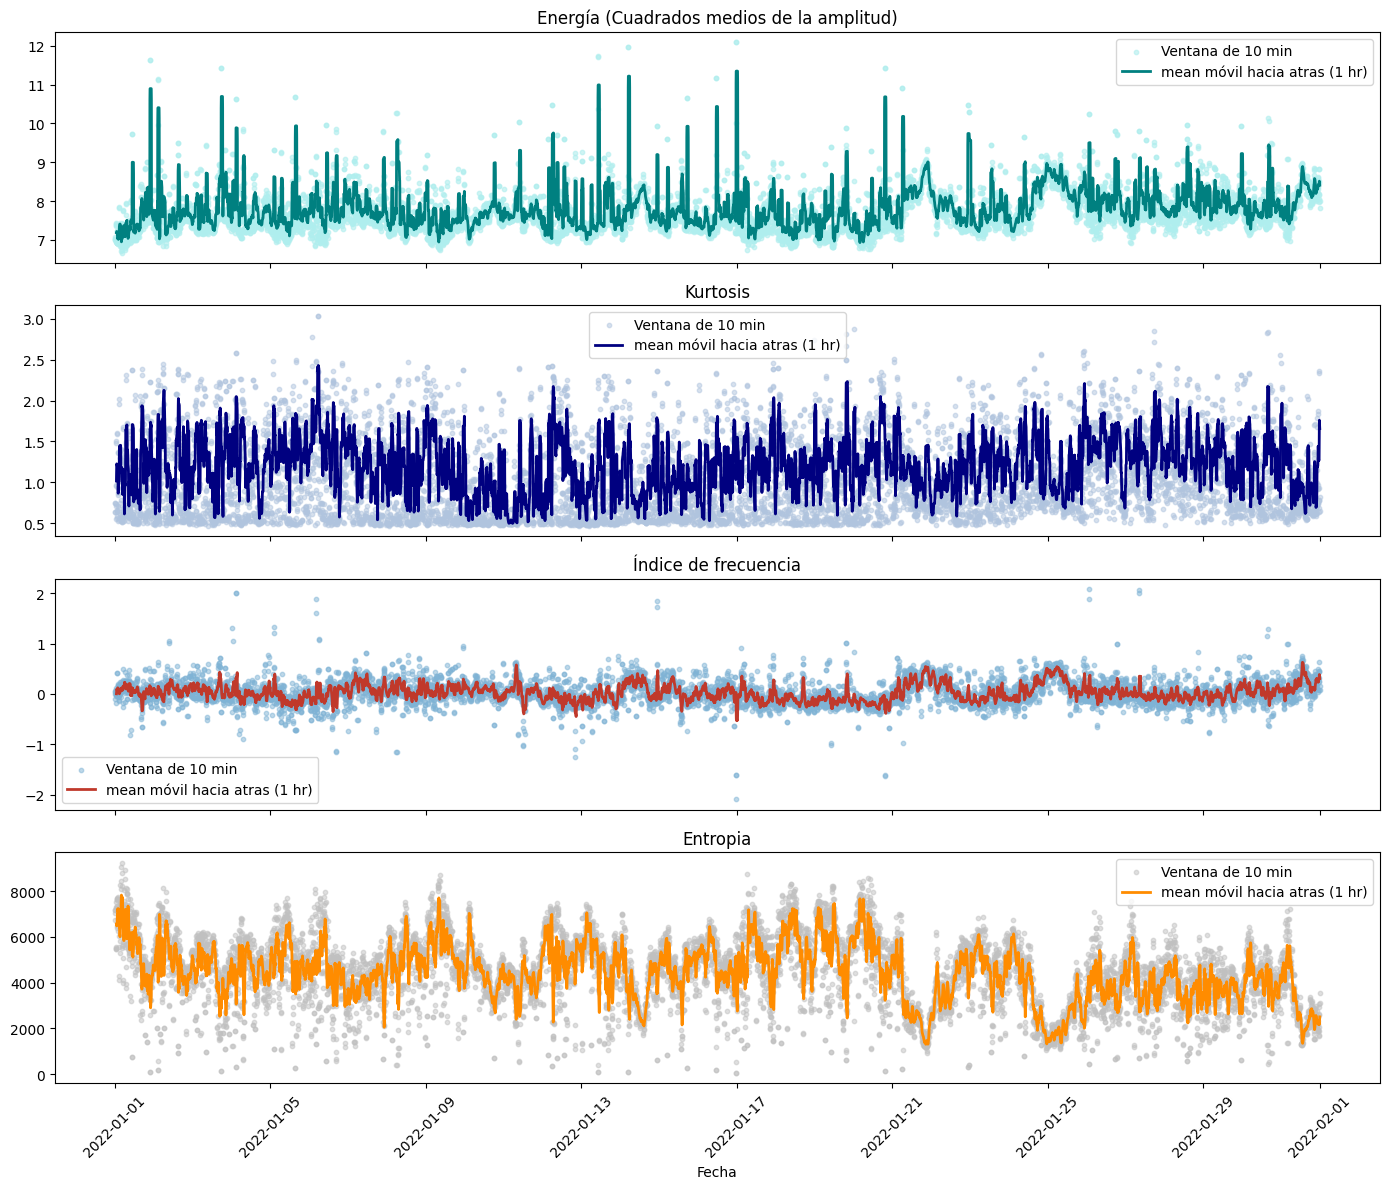

In [5]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
axes[0].scatter(features_df_run['timestamp'], features_df_run['energy'], color='paleturquoise', s=10, alpha=0.6, label="Ventana de 10 min")
axes[0].plot(features_df_run['timestamp'], features_df_run['energy_movil_mean'], color='teal', linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(loc='best')

axes[1].scatter(features_df_run['timestamp'], features_df_run['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[1].plot(features_df_run['timestamp'], features_df_run['kurtosis_mobile_mean'], color='navy', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[1].set_title('Kurtosis')
axes[1].legend(loc='best')

axes[2].scatter(features_df_run['timestamp'], features_df_run['frequency_index'], color='#7FB3D5', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[2].plot(features_df_run['timestamp'], features_df_run['frequency_index_movil_mean'], color='#C0392B', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[2].set_title('Índice de frecuencia')
axes[2].legend(loc='best')

axes[3].scatter(features_df_run['timestamp'], features_df_run['entropy'], color='silver', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[3].plot(features_df_run['timestamp'], features_df_run['entropy_movil_mean'], color='darkorange', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(loc='best')

plt.xticks(rotation=45)
plt.tight_layout()

# Clustering model

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

In [7]:
clustering_data_run = features_df_run[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_run = clustering_data_run.dropna()

# Select columns to scale
cols_to_scale =  [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
#scaler.fit(clustering_data)

scaled_data = scaler.fit_transform(clustering_data_run[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale, index=clustering_data_run.index)


X_run = df_scaled[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]



In [8]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(X_run)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(X_run, km_model.labels_))

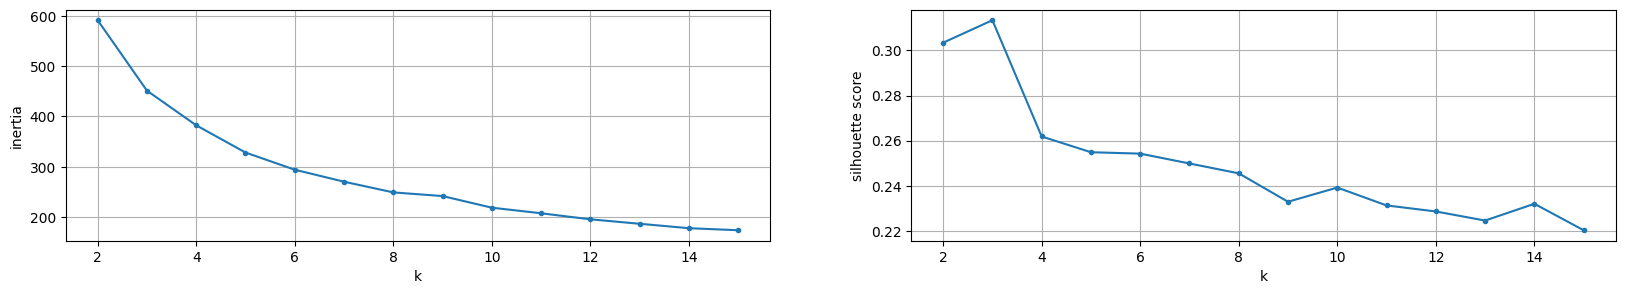

In [9]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [10]:
# Repite k-means con el mejor número k
km_model_1 = KMeans(n_clusters=3).fit(X_run)
distances = km_model_1.transform(X_run)

#clustering_data = X
clustering_data_run['timestamp'] = features_df['timestamp']

clustering_data_run['labels'] = km_model_1.labels_


clustering_data_run['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model_1.labels_)]

#clustering_data_run['log_distance_to_centroid'] = np.log(clustering_data_run['distance_to_centroid'])


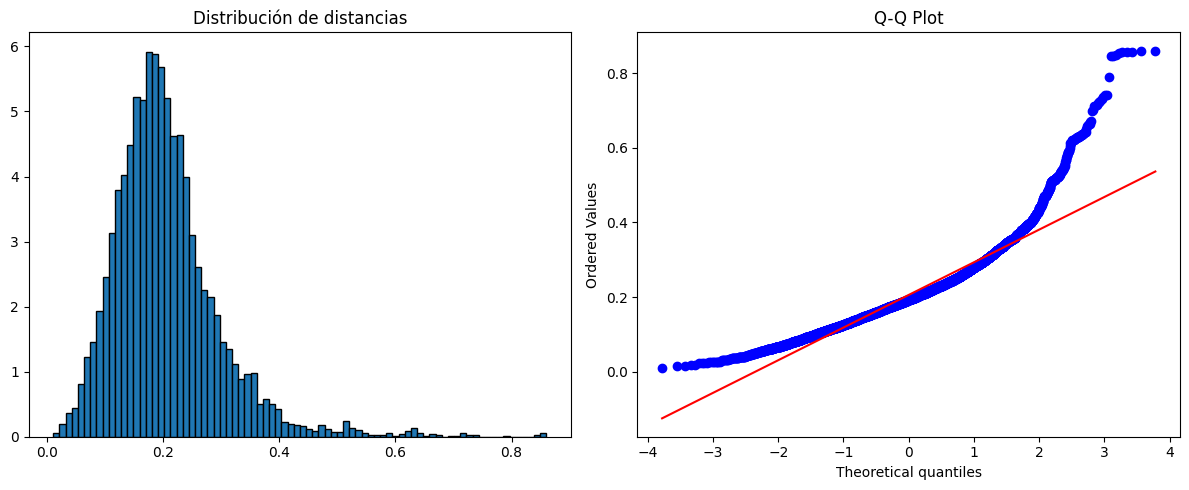

In [11]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data_run['distance_to_centroid'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data_run['distance_to_centroid'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [12]:
"""
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data['log_distance_to_centroid'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data['log_distance_to_centroid'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()
"""

"\nfig, axes = plt.subplots(1, 2, figsize=(12, 5))\n\n# Histograma\naxes[0].hist(clustering_data['log_distance_to_centroid'], bins=80, density=True, edgecolor='black')\naxes[0].set_title('Distribución de distancias')\n\n# Q-Q plot\nstats.probplot(clustering_data['log_distance_to_centroid'], plot=axes[1])\naxes[1].set_title('Q-Q Plot')\n\nplt.tight_layout()\nplt.show()\n"

In [13]:
# Rango de valores típicos (suponiendo normalidad) para el logaritmo de las distancias
#np.mean(clustering_data['log_distance_to_centroid']) - 3*np.std(clustering_data['log_distance_to_centroid']) , np.mean(clustering_data['log_distance_to_centroid']) + 3*np.std(clustering_data['log_distance_to_centroid'])

In [14]:
# Rango de valores observados para el logaritmo de las distancias
#np.min(clustering_data['log_distance_to_centroid']),np.max(clustering_data['log_distance_to_centroid'])

In [15]:
# Rango de valores observados
np.min(clustering_data_run['distance_to_centroid']),np.max(clustering_data_run['distance_to_centroid'])

(0.011191852826878144, 0.8600564848801262)

In [16]:
# Cálculo de cuartiles y cota superior de valores
Q1 = clustering_data_run['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data_run['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 3*IQR
#1.5
upper

0.5356491327034048

In [17]:
# Clasificamos los valores observados como típicos y atípicos
clustering_data_run['outliers'] = clustering_data_run['distance_to_centroid'] > upper
#clustering_data['outliers']

In [18]:
# Sort clustering data by timestamp
clustering_data_run = clustering_data_run.sort_values(by='timestamp')

In [19]:
# Distribución de número de observaciones por grupo
clustering_data_run[['labels','timestamp']].groupby('labels').count()

,timestamp
labels,
0,3212
1,4255
2,1416


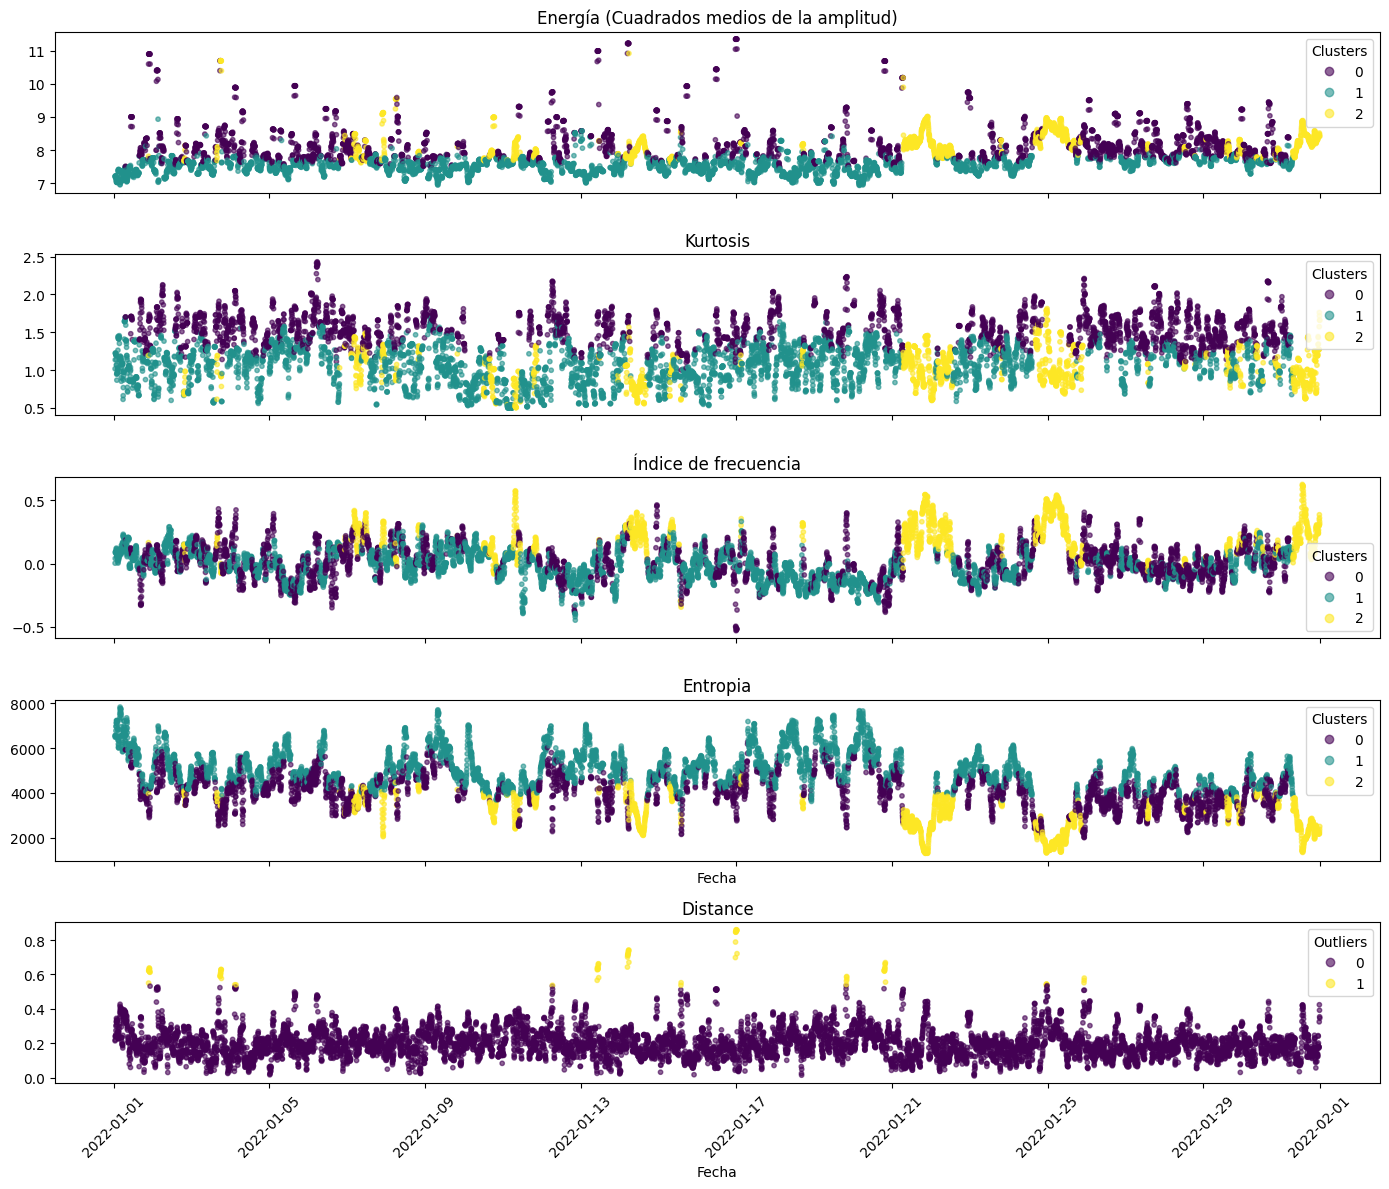

In [20]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_run['timestamp'], clustering_data_run['energy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_run['timestamp'], clustering_data_run['kurtosis_mobile_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_run['timestamp'], clustering_data_run['frequency_index_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_run['timestamp'], clustering_data_run['entropy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_run['timestamp'], clustering_data_run['distance_to_centroid'], c=clustering_data_run['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [21]:
features_df_rest = features_df[(features_df['timestamp']<"2025-01-01") & (features_df['timestamp']>="2022-02-01")]

clustering_data_rest = features_df_rest[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_rest = clustering_data_rest.dropna()


scaled_data_rest = scaler.transform(clustering_data_rest[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_rest = pd.DataFrame(scaled_data_rest, columns=cols_to_scale, index=clustering_data_rest.index)



X_rest = df_scaled_rest[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

In [22]:
clustering_data_rest

,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean
8897,8.393811,1.661201,0.273803,2568.654698
8898,8.368427,1.661031,0.251328,2632.398663
8899,8.331916,1.660930,0.233178,2718.468674
8900,8.318658,1.660575,0.221038,2781.344684
8901,8.329291,1.775273,0.159708,2764.549794
...,...,...,...,...
244232,8.475240,1.661013,0.164519,2422.352334
244233,8.499053,1.732388,0.143333,2391.615290
244234,8.420484,1.676854,0.156674,2462.867215
244235,8.336336,1.595239,0.172988,2519.611226


In [23]:
# Predict clusters for new data using the same centroids
labels_2 = km_model_1.predict(X_rest)

# Add labels and timestamp to the new dataframe
#clustering_data_2 = X_2.copy()
clustering_data_rest['timestamp'] = features_df_rest['timestamp']
clustering_data_rest['labels'] = labels_2

distances_2 = km_model_1.transform(X_rest)



clustering_data_rest['distance_to_centroid'] = [distances_2[i, label] for i, label in enumerate(labels_2)]
clustering_data_rest['outliers'] = clustering_data_rest['distance_to_centroid'] > upper


clustering_data_all = pd.concat([clustering_data_run, clustering_data_rest], axis=0)

# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

clustering_data_all


,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean,timestamp,labels,distance_to_centroid,outliers
10,7.189824,1.016756,0.002807,6566.963119,2022-01-01 00:55:00,1,0.214913,False
11,7.202035,1.135282,0.040282,6541.763823,2022-01-01 01:00:00,1,0.220074,False
12,7.217582,1.225977,0.087732,6484.417105,2022-01-01 01:05:00,1,0.239160,False
13,7.214921,1.221882,0.091360,6501.124913,2022-01-01 01:10:00,1,0.241860,False
14,7.209869,1.217271,0.082832,6542.602102,2022-01-01 01:15:00,1,0.243429,False
...,...,...,...,...,...,...,...,...
244232,8.475240,1.661013,0.164519,2422.352334,2024-04-30 23:35:00,0,0.287396,False
244233,8.499053,1.732388,0.143333,2391.615290,2024-04-30 23:40:00,0,0.293358,False
244234,8.420484,1.676854,0.156674,2462.867215,2024-04-30 23:45:00,0,0.278616,False
244235,8.336336,1.595239,0.172988,2519.611226,2024-04-30 23:50:00,0,0.270233,False


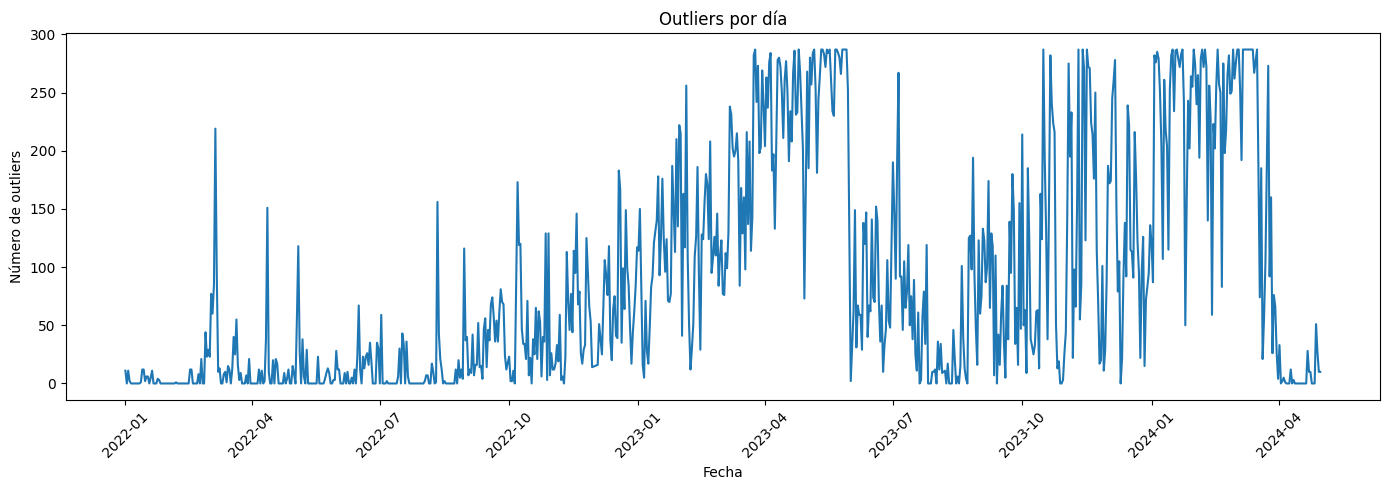

In [24]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day = clustering_data_all.groupby('date').size()
outliers_by_day = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day = outliers_by_day.reindex(total_by_day.index, fill_value=0)

outliers_by_day = outliers_by_day.reset_index()
outliers_by_day.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
outliers_by_day.to_csv('first_outliers_file.csv')


In [26]:
date_reprocess = outliers_by_day[outliers_by_day['outliers'] > 150]['date'].iloc[0]

outliers_by_day_1 = outliers_by_day[outliers_by_day['date']<=date_reprocess]

In [27]:
date_reprocess

datetime.date(2022, 3, 6)

In [28]:
from datetime import timedelta


features_df_run = features_run = features_df[features_df['timestamp'] <= pd.Timestamp(date_reprocess) + timedelta(days=1)]

features_df_run

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean
0,2022-01-01 00:05:00,7.074324,0.633977,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,7.020175,0.632777,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,7.011306,0.751629,None,7175.473832,0.032564,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,7.010472,0.750180,None,7186.277967,0.065660,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,6.986411,0.732571,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
18650,2022-03-06 23:35:00,9.428050,0.521150,None,759.342086,-0.246124,9.382968,0.523011,-0.249276,804.498473
18651,2022-03-06 23:40:00,9.447843,0.512824,None,743.156458,-0.269218,9.405417,0.520679,-0.253252,780.909250
18652,2022-03-06 23:45:00,9.539397,0.537444,None,683.338379,-0.294109,9.431832,0.522627,-0.262939,759.592267
18653,2022-03-06 23:50:00,9.635727,0.525627,None,621.693432,-0.314574,9.461849,0.521044,-0.270432,740.673324


In [29]:
clustering_data_run = features_df_run[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_run = clustering_data_run.dropna()

# Select columns to scale
cols_to_scale =  [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
#scaler.fit(clustering_data)

scaled_data = scaler.fit_transform(clustering_data_run[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale, index=clustering_data_run.index)


X_run = df_scaled[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]



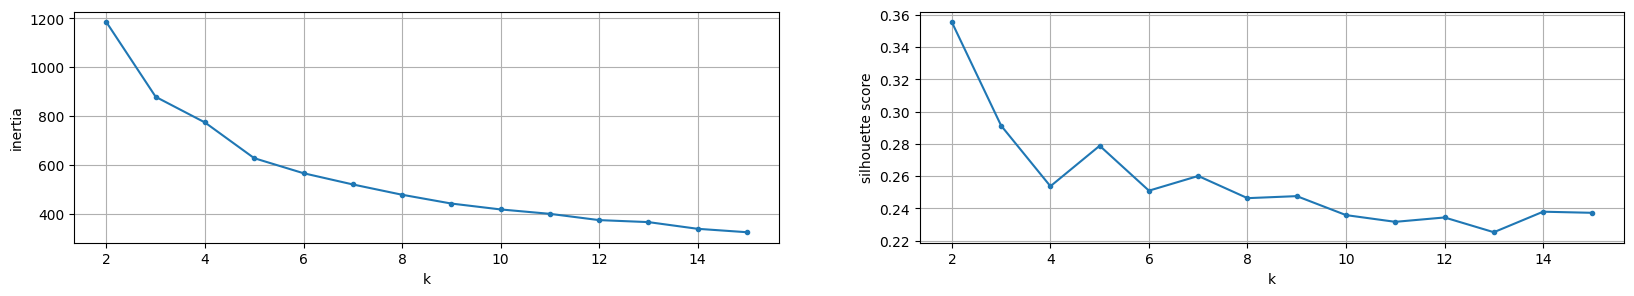

In [30]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(X_run)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(X_run, km_model.labels_))

# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [31]:
# Repite k-means con el mejor número k
km_model_2 = KMeans(n_clusters=4).fit(X_run)
distances = km_model_2.transform(X_run)

#clustering_data = X
clustering_data_run['timestamp'] = features_df['timestamp']

clustering_data_run['labels'] = km_model_2.labels_


clustering_data_run['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model_2.labels_)]


Q1 = clustering_data_run['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data_run['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 3*IQR

upper

0.5588435423383585

In [32]:
clustering_data_run['outliers'] = clustering_data_run['distance_to_centroid'] > upper
clustering_data_run = clustering_data_run.sort_values(by='timestamp')

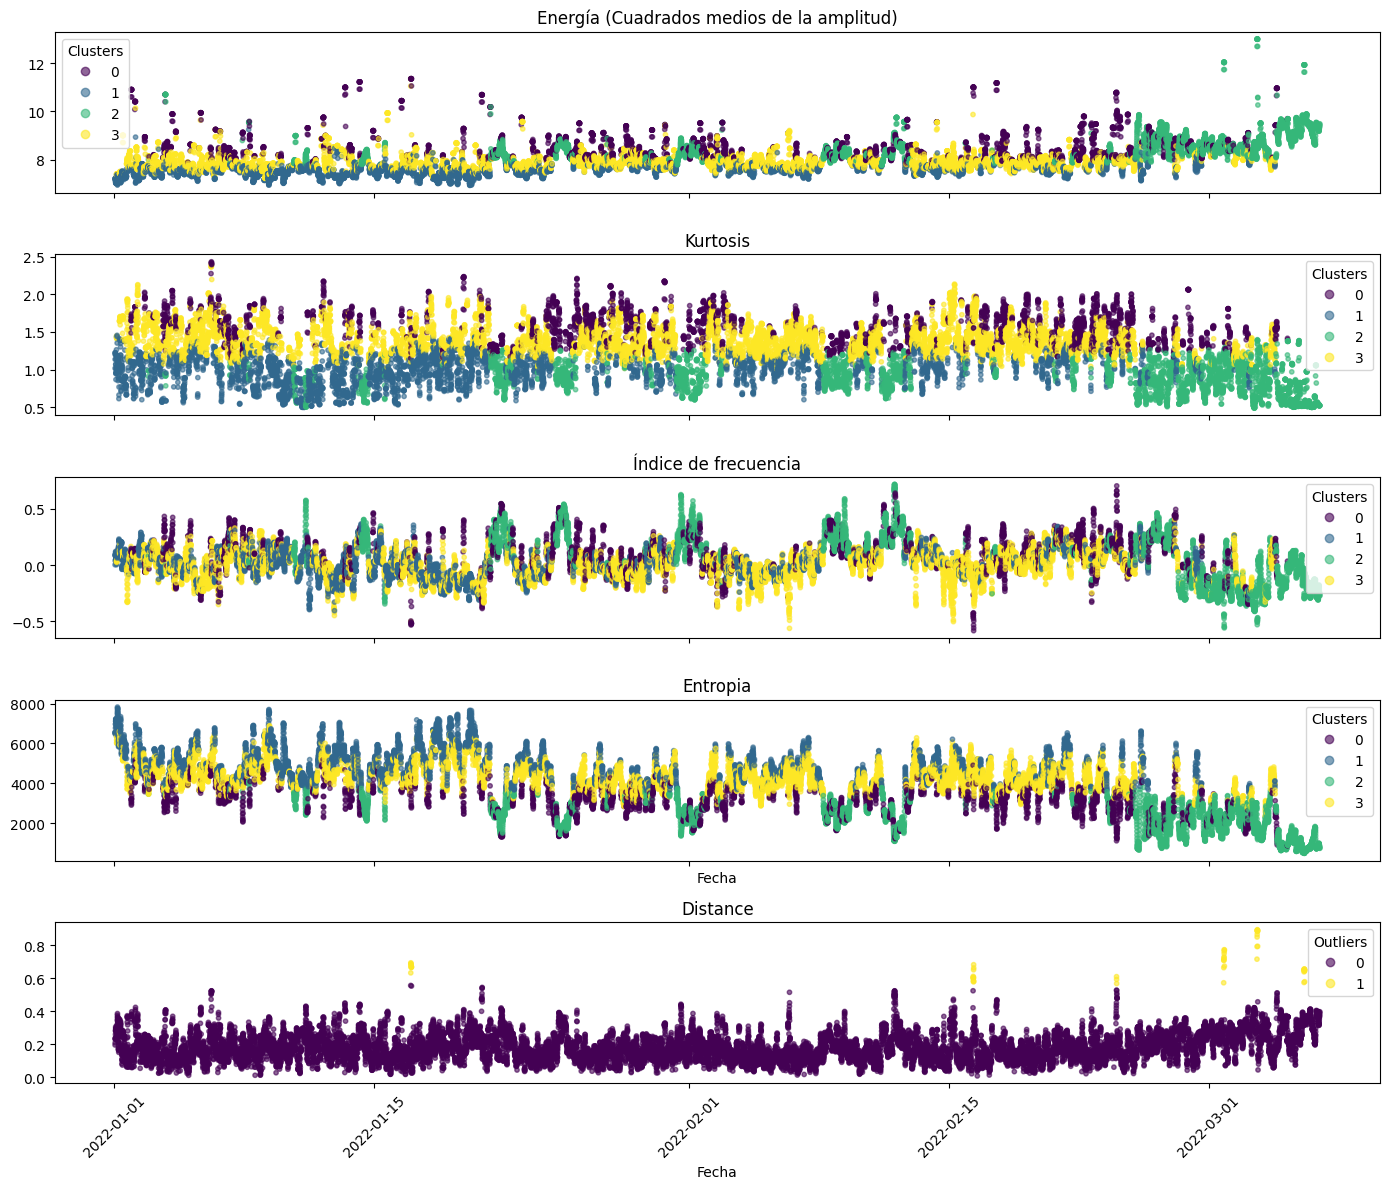

In [33]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_run['timestamp'], clustering_data_run['energy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_run['timestamp'], clustering_data_run['kurtosis_mobile_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_run['timestamp'], clustering_data_run['frequency_index_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_run['timestamp'], clustering_data_run['entropy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_run['timestamp'], clustering_data_run['distance_to_centroid'], c=clustering_data_run['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [34]:
features_df_rest = features_df_rest[(features_df_rest['timestamp']<"2025-06-01") & (features_df_rest['timestamp']> pd.Timestamp(date_reprocess) + timedelta(days=1))]

clustering_data_rest = features_df_rest[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_rest = clustering_data_rest.dropna()


scaled_data_2 = scaler.transform(clustering_data_rest[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_2 = pd.DataFrame(scaled_data_2, columns=cols_to_scale, index=clustering_data_rest.index)



X_rest = df_scaled_2[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Predict clusters for new data using the same centroids
labels_2 = km_model_2.predict(X_rest)

# Add labels and timestamp to the new dataframe
#clustering_data_2 = X_2.copy()
clustering_data_rest['timestamp'] = features_df_rest['timestamp']
clustering_data_rest['labels'] = labels_2

distances_2 = km_model_2.transform(X_rest)



clustering_data_rest['distance_to_centroid'] = [distances_2[i, label] for i, label in enumerate(labels_2)]
clustering_data_rest['outliers'] = clustering_data_rest['distance_to_centroid'] > upper


clustering_data_all = pd.concat([clustering_data_run, clustering_data_rest], axis=0)

# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

clustering_data_all

,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean,timestamp,labels,distance_to_centroid,outliers
10,7.189824,1.016756,0.002807,6566.963119,2022-01-01 00:55:00,1,0.196092,False
11,7.202035,1.135282,0.040282,6541.763823,2022-01-01 01:00:00,1,0.209101,False
12,7.217582,1.225977,0.087732,6484.417105,2022-01-01 01:05:00,1,0.231731,False
13,7.214921,1.221882,0.091360,6501.124913,2022-01-01 01:10:00,1,0.233258,False
14,7.209869,1.217271,0.082832,6542.602102,2022-01-01 01:15:00,1,0.234729,False
...,...,...,...,...,...,...,...,...
244232,8.475240,1.661013,0.164519,2422.352334,2024-04-30 23:35:00,0,0.100793,False
244233,8.499053,1.732388,0.143333,2391.615290,2024-04-30 23:40:00,0,0.116786,False
244234,8.420484,1.676854,0.156674,2462.867215,2024-04-30 23:45:00,0,0.100513,False
244235,8.336336,1.595239,0.172988,2519.611226,2024-04-30 23:50:00,0,0.096782,False


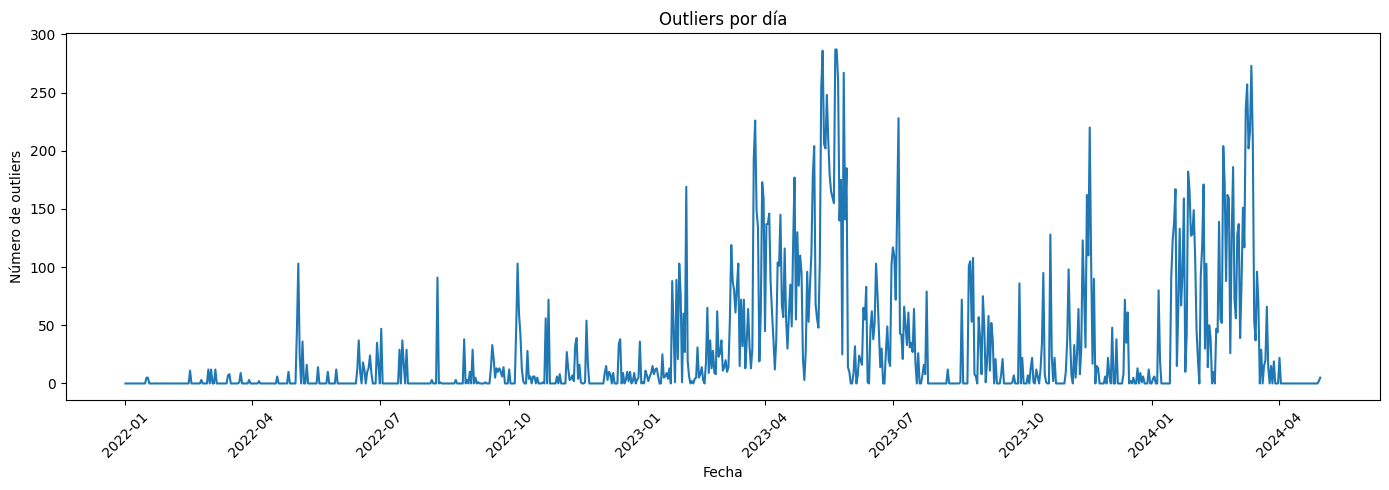

In [35]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day_2 = clustering_data_all.groupby('date').size()
outliers_by_day_2 = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day_2 = outliers_by_day_2.reindex(total_by_day.index, fill_value=0)

outliers_by_day_2 = outliers_by_day_2.reset_index()
outliers_by_day_2.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day_2['date'], outliers_by_day_2['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

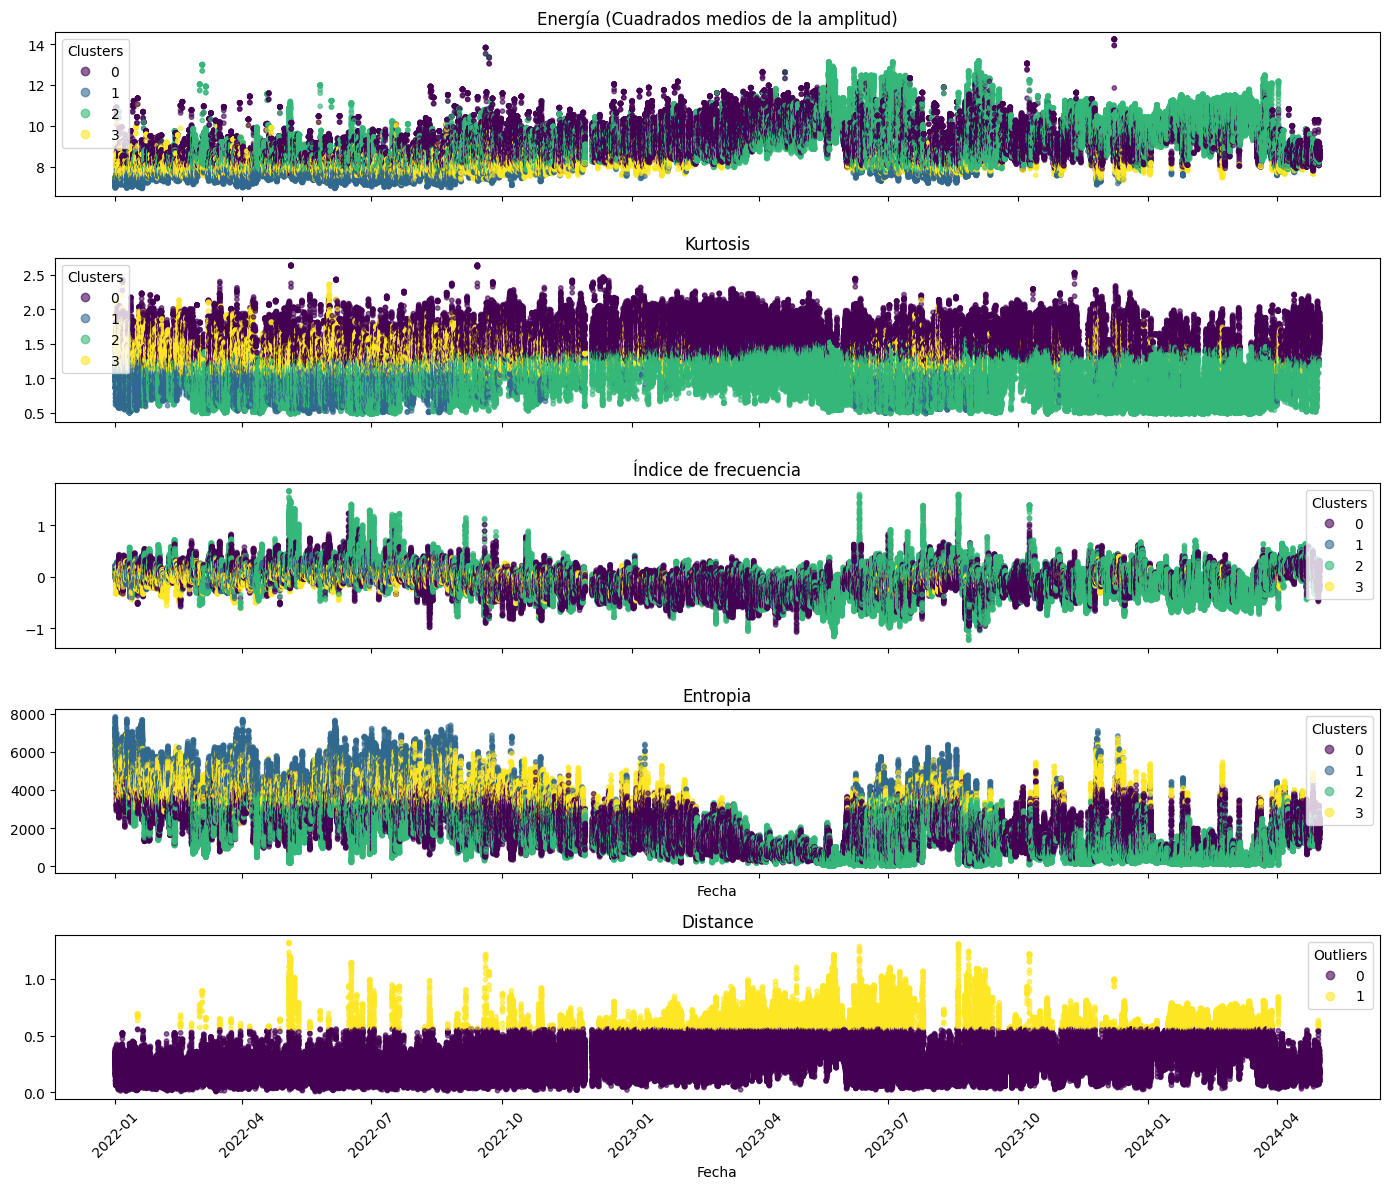

In [36]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all['timestamp'], clustering_data_all['energy_movil_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all['timestamp'], clustering_data_all['kurtosis_mobile_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all['timestamp'], clustering_data_all['frequency_index_movil_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all['timestamp'], clustering_data_all['entropy_movil_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_all['timestamp'], clustering_data_all['distance_to_centroid'], c=clustering_data_all['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [37]:
date_reprocess = outliers_by_day_2[outliers_by_day_2['outliers'] > 150]['date'].iloc[0]

outliers_by_day_3 = outliers_by_day_2[outliers_by_day_2['date']<=date_reprocess]


date_reprocess

datetime.date(2023, 2, 4)

In [38]:

features_df_run = features_run = features_df[features_df['timestamp'] <= pd.Timestamp(date_reprocess) + timedelta(days=1)]

features_df_run

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean
0,2022-01-01 00:05:00,7.074324,0.633977,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,7.020175,0.632777,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,7.011306,0.751629,None,7175.473832,0.032564,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,7.010472,0.750180,None,7186.277967,0.065660,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,6.986411,0.732571,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
114795,2023-02-04 23:35:00,8.942666,2.154587,None,1518.945473,-0.231507,11.095625,2.060979,-0.255219,801.572245
114796,2023-02-04 23:40:00,9.774953,1.681928,None,658.038308,-0.394736,11.097433,2.072919,-0.295742,652.897227
114797,2023-02-04 23:45:00,9.759575,1.695663,None,666.170969,-0.356885,10.845411,2.017812,-0.294678,704.803599
114798,2023-02-04 23:50:00,9.287054,1.656628,None,1046.954871,-0.212111,10.114131,1.957692,-0.281128,791.499266


In [39]:
clustering_data_run = features_df_run[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_run = clustering_data_run.dropna()

# Select columns to scale
cols_to_scale =  [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
#scaler.fit(clustering_data)

scaled_data = scaler.fit_transform(clustering_data_run[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale, index=clustering_data_run.index)


X_run = df_scaled[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]


In [40]:
X_run

,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean
10,0.037459,0.248437,0.371317,0.835136
11,0.039231,0.303298,0.385426,0.831853
12,0.041486,0.345278,0.403290,0.824383
13,0.041100,0.343383,0.404656,0.826560
14,0.040367,0.341248,0.401445,0.831963
...,...,...,...,...
114795,0.604033,0.731772,0.274174,0.084136
114796,0.604296,0.737298,0.258917,0.064769
114797,0.567738,0.711791,0.259318,0.071531
114798,0.461658,0.683964,0.264419,0.082824


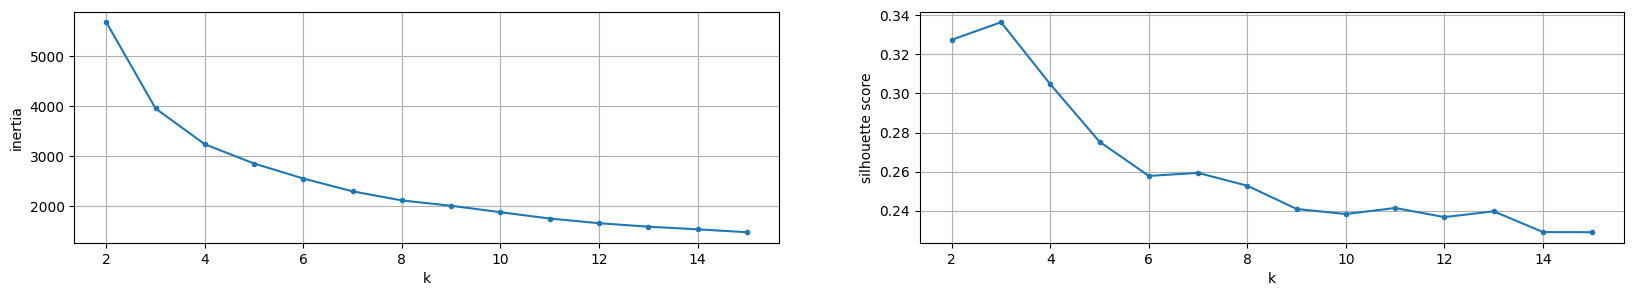

In [41]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(X_run)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(X_run, km_model.labels_))

# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [42]:
# Repite k-means con el mejor número k
km_model_3= KMeans(n_clusters=3).fit(X_run)
distances = km_model_3.transform(X_run)

#clustering_data = X
clustering_data_run['timestamp'] = features_df['timestamp']

clustering_data_run['labels'] = km_model_3.labels_


clustering_data_run['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model_3.labels_)]


Q1 = clustering_data_run['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data_run['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 3*IQR

upper

0.47863058944921444

In [43]:
clustering_data_run['outliers'] = clustering_data_run['distance_to_centroid'] > upper
clustering_data_run = clustering_data_run.sort_values(by='timestamp')

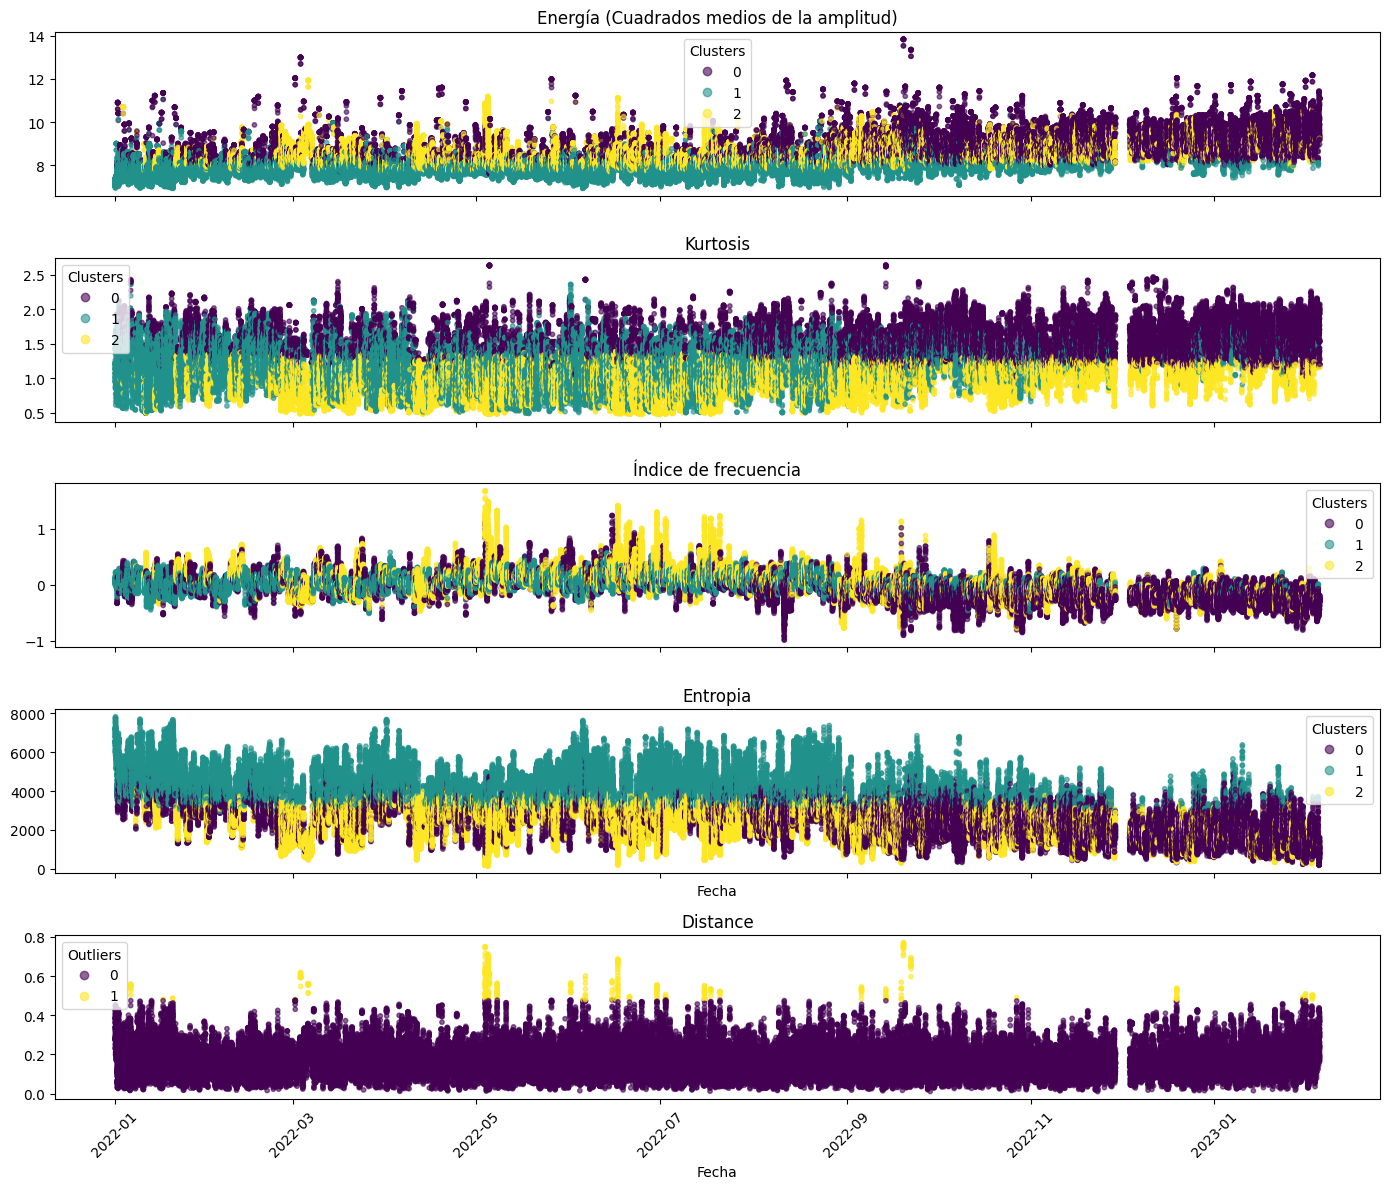

In [44]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_run['timestamp'], clustering_data_run['energy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_run['timestamp'], clustering_data_run['kurtosis_mobile_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_run['timestamp'], clustering_data_run['frequency_index_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_run['timestamp'], clustering_data_run['entropy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_run['timestamp'], clustering_data_run['distance_to_centroid'], c=clustering_data_run['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [45]:
features_df_rest = features_df_rest[(features_df_rest['timestamp']<"2025-06-01") & (features_df_rest['timestamp']> pd.Timestamp(date_reprocess) + timedelta(days=1))]

clustering_data_rest = features_df_rest[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_rest = clustering_data_rest.dropna()


scaled_data_2 = scaler.transform(clustering_data_rest[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_2 = pd.DataFrame(scaled_data_2, columns=cols_to_scale, index=clustering_data_rest.index)



X_rest = df_scaled_2[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Predict clusters for new data using the same centroids
labels_2 = km_model_3.predict(X_rest)

# Add labels and timestamp to the new dataframe
#clustering_data_2 = X_2.copy()
clustering_data_rest['timestamp'] = features_df_rest['timestamp']
clustering_data_rest['labels'] = labels_2

distances_2 = km_model_3.transform(X_rest)



clustering_data_rest['distance_to_centroid'] = [distances_2[i, label] for i, label in enumerate(labels_2)]
clustering_data_rest['outliers'] = clustering_data_rest['distance_to_centroid'] > upper


clustering_data_all = pd.concat([clustering_data_run, clustering_data_rest], axis=0)

# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

clustering_data_all

,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean,timestamp,labels,distance_to_centroid,outliers
10,7.189824,1.016756,0.002807,6566.963119,2022-01-01 00:55:00,1,0.296353,False
11,7.202035,1.135282,0.040282,6541.763823,2022-01-01 01:00:00,1,0.282103,False
12,7.217582,1.225977,0.087732,6484.417105,2022-01-01 01:05:00,1,0.273986,False
13,7.214921,1.221882,0.091360,6501.124913,2022-01-01 01:10:00,1,0.276161,False
14,7.209869,1.217271,0.082832,6542.602102,2022-01-01 01:15:00,1,0.281231,False
...,...,...,...,...,...,...,...,...
244232,8.475240,1.661013,0.164519,2422.352334,2024-04-30 23:35:00,0,0.151876,False
244233,8.499053,1.732388,0.143333,2391.615290,2024-04-30 23:40:00,0,0.151663,False
244234,8.420484,1.676854,0.156674,2462.867215,2024-04-30 23:45:00,0,0.157191,False
244235,8.336336,1.595239,0.172988,2519.611226,2024-04-30 23:50:00,0,0.169169,False


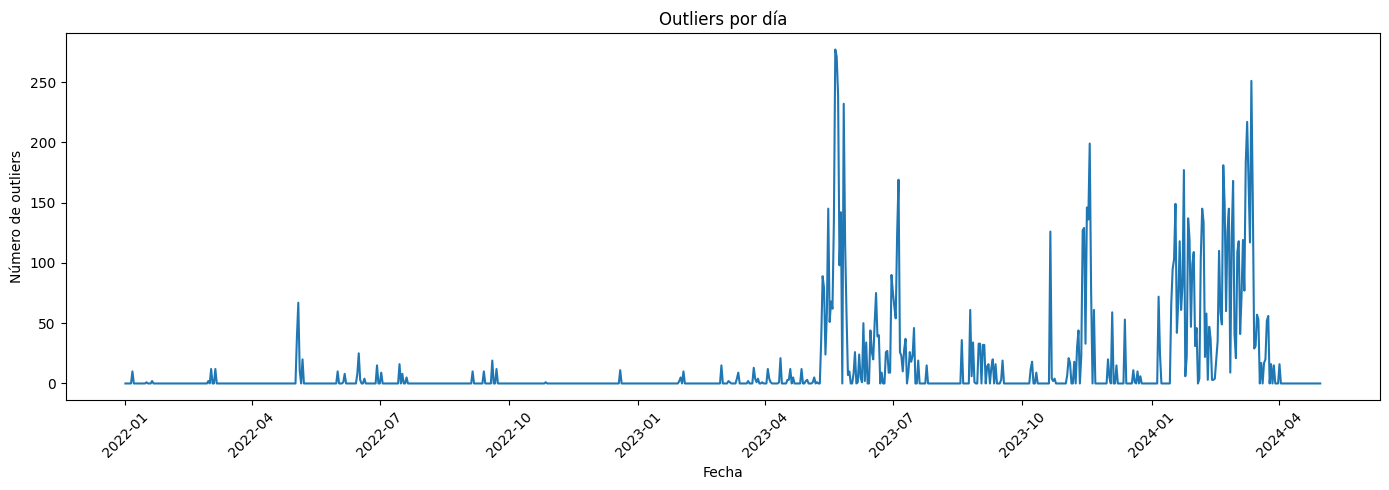

In [46]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day_3 = clustering_data_all.groupby('date').size()
outliers_by_day_4 = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day_4 = outliers_by_day_4.reindex(total_by_day.index, fill_value=0)

outliers_by_day_4 = outliers_by_day_4.reset_index()
outliers_by_day_4.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day_4['date'], outliers_by_day_4['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

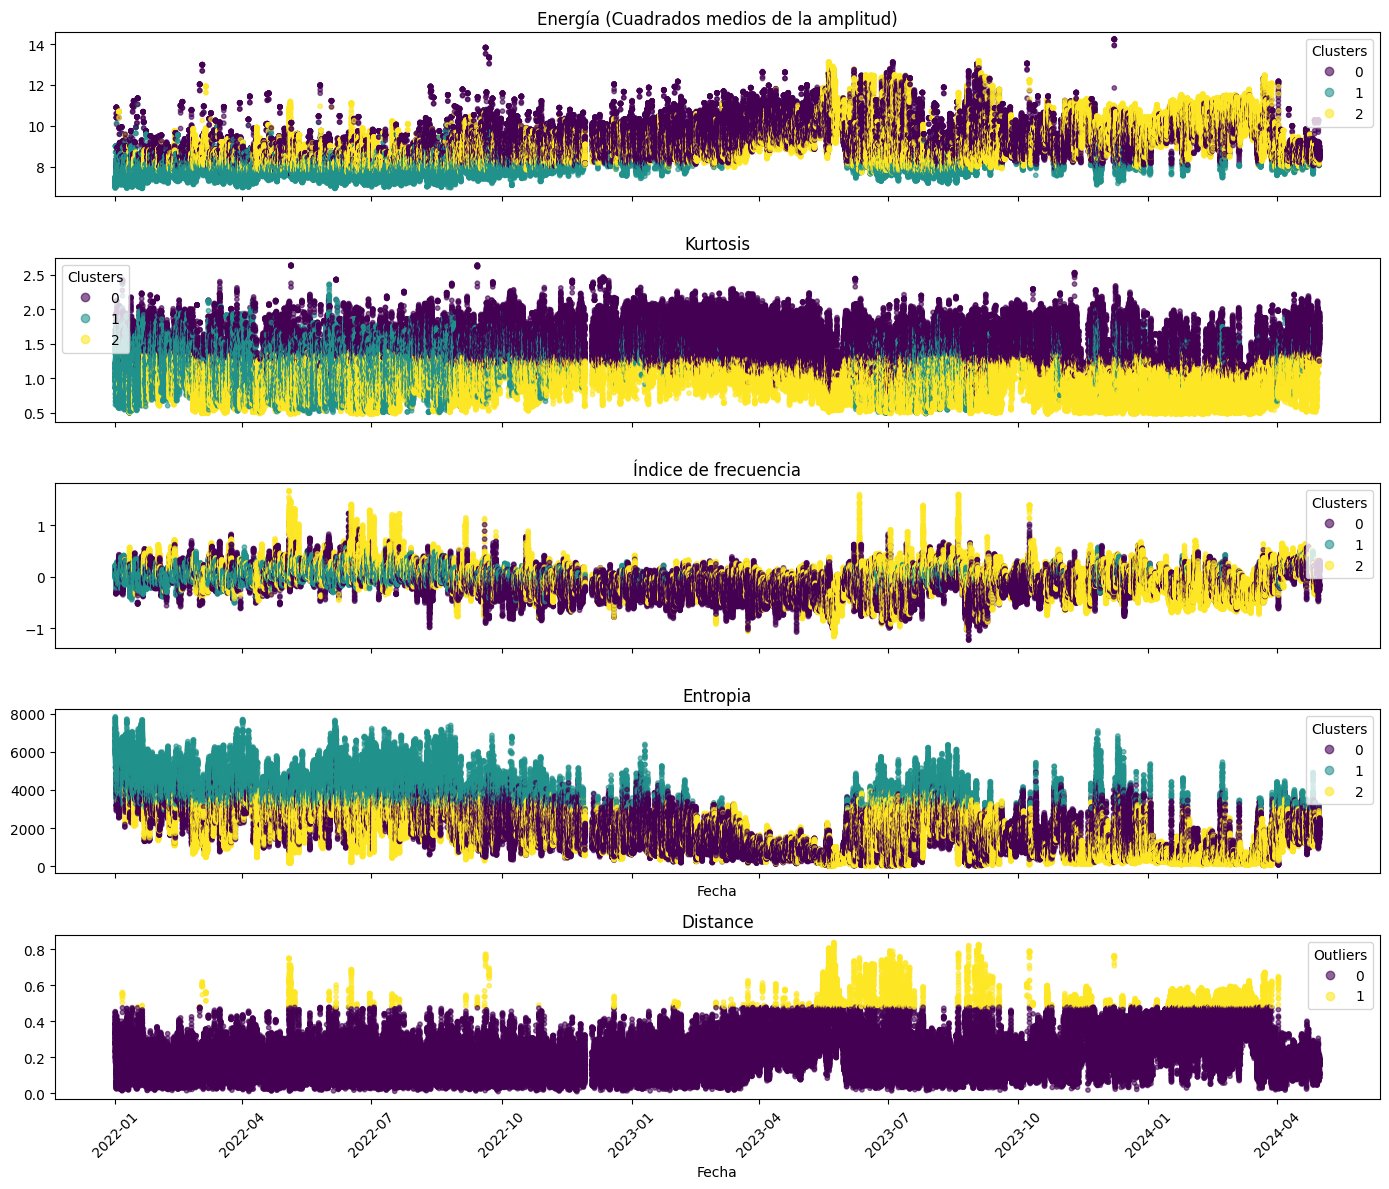

In [47]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all['timestamp'], clustering_data_all['energy_movil_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all['timestamp'], clustering_data_all['kurtosis_mobile_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all['timestamp'], clustering_data_all['frequency_index_movil_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all['timestamp'], clustering_data_all['entropy_movil_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_all['timestamp'], clustering_data_all['distance_to_centroid'], c=clustering_data_all['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [48]:
date_reprocess = outliers_by_day_4[outliers_by_day_4['outliers'] > 150]['date'].iloc[0]

outliers_by_day_5 = outliers_by_day_4[outliers_by_day_4['date']<=date_reprocess]


date_reprocess

datetime.date(2023, 5, 21)

In [49]:
features_df_run = features_run = features_df[features_df['timestamp'] <= pd.Timestamp(date_reprocess) + timedelta(days=1)]

features_df_run

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean
0,2022-01-01 00:05:00,7.074324,0.633977,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,7.020175,0.632777,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,7.011306,0.751629,None,7175.473832,0.032564,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,7.010472,0.750180,None,7186.277967,0.065660,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,6.986411,0.732571,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
145217,2023-05-21 23:35:00,12.234238,0.521531,None,44.967917,-0.638349,12.562897,0.543256,-0.694997,33.409415
145218,2023-05-21 23:40:00,12.327477,0.543443,None,41.056916,-0.619119,12.523542,0.547706,-0.695344,34.758789
145219,2023-05-21 23:45:00,12.299536,0.566427,None,42.486126,-0.657367,12.490596,0.552091,-0.698718,36.022825
145220,2023-05-21 23:50:00,12.388265,0.614162,None,39.238209,-0.781662,12.466321,0.561007,-0.716874,36.889441


In [50]:
clustering_data_run = features_df_run[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_run = clustering_data_run.dropna()

# Select columns to scale
cols_to_scale =  [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
#scaler.fit(clustering_data)

scaled_data = scaler.fit_transform(clustering_data_run[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale, index=clustering_data_run.index)


X_run = df_scaled[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

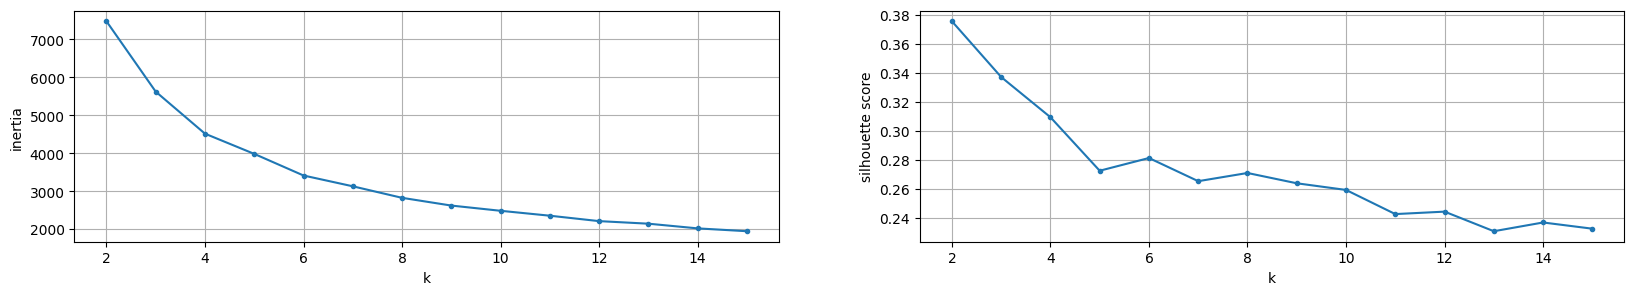

In [51]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(X_run)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(X_run, km_model.labels_))

# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [58]:
# Repite k-means con el mejor número k
km_model_4= KMeans(n_clusters=6).fit(X_run)
distances = km_model_4.transform(X_run)

#clustering_data = X
clustering_data_run['timestamp'] = features_df['timestamp']

clustering_data_run['labels'] = km_model_4.labels_


clustering_data_run['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model_4.labels_)]


Q1 = clustering_data_run['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data_run['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 3*IQR

upper

0.3713169740226844

In [59]:
clustering_data_run['outliers'] = clustering_data_run['distance_to_centroid'] > upper
clustering_data_run = clustering_data_run.sort_values(by='timestamp')

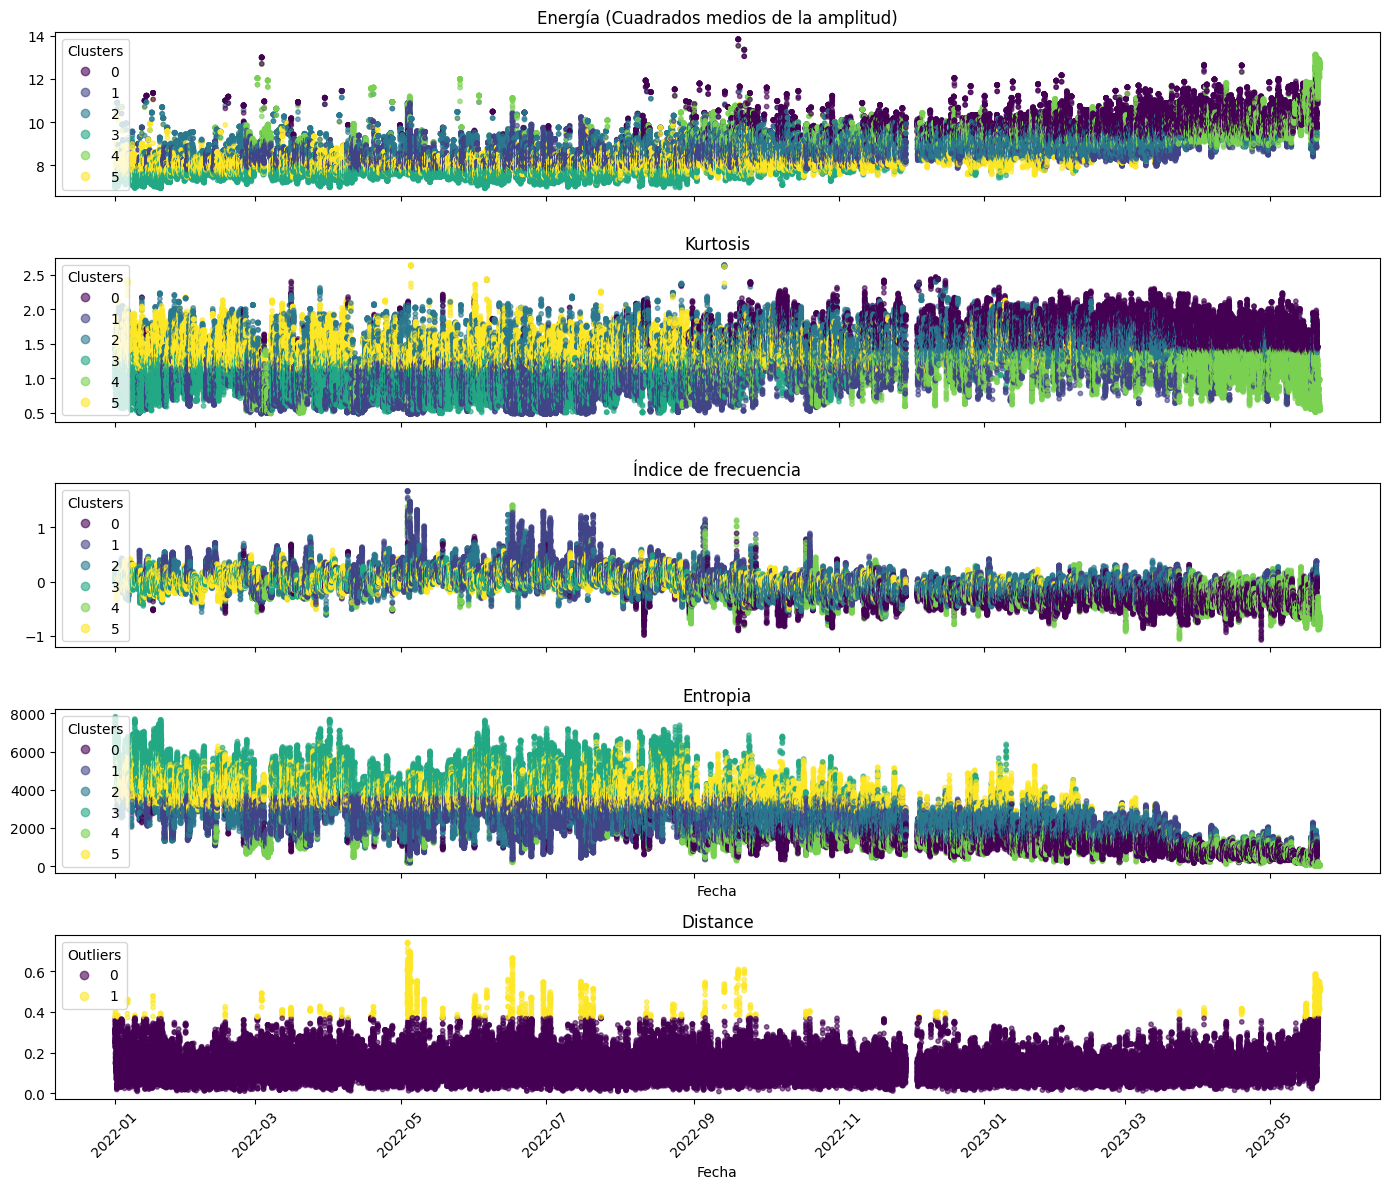

In [60]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_run['timestamp'], clustering_data_run['energy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_run['timestamp'], clustering_data_run['kurtosis_mobile_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_run['timestamp'], clustering_data_run['frequency_index_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_run['timestamp'], clustering_data_run['entropy_movil_mean'], c=clustering_data_run['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_run['timestamp'], clustering_data_run['distance_to_centroid'], c=clustering_data_run['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [62]:
features_df_rest = features_df_rest[(features_df_rest['timestamp']<"2025-06-01") & (features_df_rest['timestamp']> pd.Timestamp(date_reprocess) + timedelta(days=1))]

clustering_data_rest = features_df_rest[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_rest = clustering_data_rest.dropna()


scaled_data_2 = scaler.transform(clustering_data_rest[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_2 = pd.DataFrame(scaled_data_2, columns=cols_to_scale, index=clustering_data_rest.index)



X_rest = df_scaled_2[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Predict clusters for new data using the same centroids
labels_2 = km_model_4.predict(X_rest)

# Add labels and timestamp to the new dataframe
#clustering_data_2 = X_2.copy()
clustering_data_rest['timestamp'] = features_df_rest['timestamp']
clustering_data_rest['labels'] = labels_2

distances_2 = km_model_4.transform(X_rest)



clustering_data_rest['distance_to_centroid'] = [distances_2[i, label] for i, label in enumerate(labels_2)]
clustering_data_rest['outliers'] = clustering_data_rest['distance_to_centroid'] > upper


clustering_data_all = pd.concat([clustering_data_run, clustering_data_rest], axis=0)

# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

clustering_data_all

,energy_movil_mean,kurtosis_mobile_mean,frequency_index_movil_mean,entropy_movil_mean,timestamp,labels,distance_to_centroid,outliers
10,7.189824,1.016756,0.002807,6566.963119,2022-01-01 00:55:00,3,0.227414,False
11,7.202035,1.135282,0.040282,6541.763823,2022-01-01 01:00:00,3,0.234817,False
12,7.217582,1.225977,0.087732,6484.417105,2022-01-01 01:05:00,3,0.245102,False
13,7.214921,1.221882,0.091360,6501.124913,2022-01-01 01:10:00,3,0.246174,False
14,7.209869,1.217271,0.082832,6542.602102,2022-01-01 01:15:00,3,0.249737,False
...,...,...,...,...,...,...,...,...
244232,8.475240,1.661013,0.164519,2422.352334,2024-04-30 23:35:00,2,0.122098,False
244233,8.499053,1.732388,0.143333,2391.615290,2024-04-30 23:40:00,2,0.129974,False
244234,8.420484,1.676854,0.156674,2462.867215,2024-04-30 23:45:00,2,0.128291,False
244235,8.336336,1.595239,0.172988,2519.611226,2024-04-30 23:50:00,2,0.132849,False


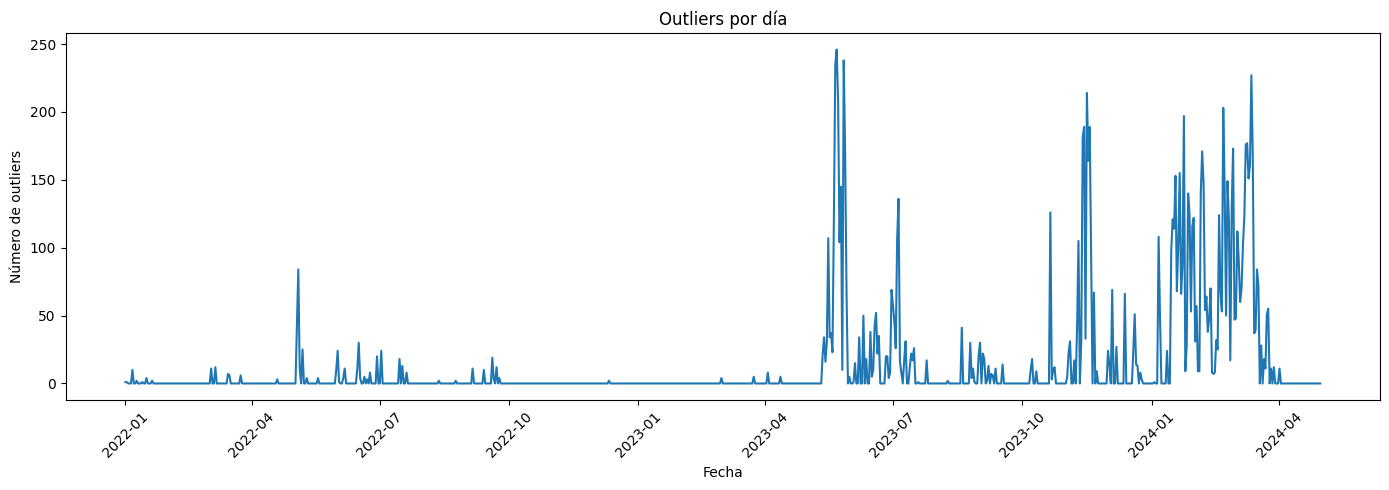

In [61]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day_3 = clustering_data_all.groupby('date').size()
outliers_by_day_4 = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day_4 = outliers_by_day_4.reindex(total_by_day.index, fill_value=0)

outliers_by_day_4 = outliers_by_day_4.reset_index()
outliers_by_day_4.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day_4['date'], outliers_by_day_4['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

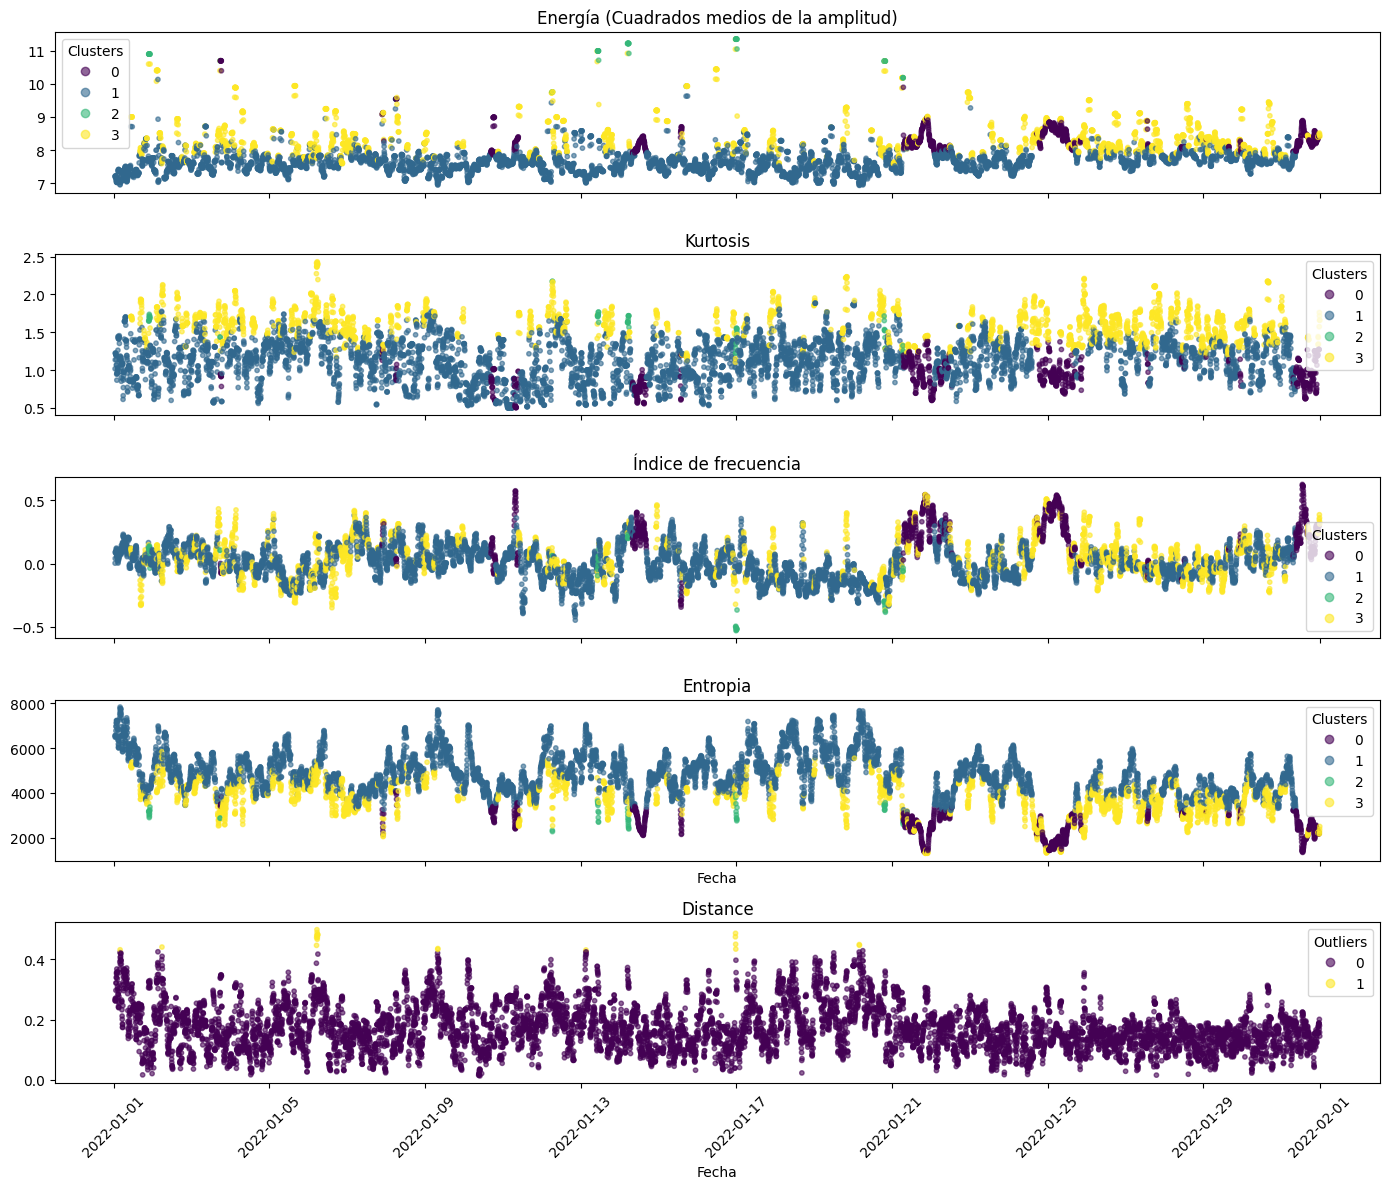

In [57]:
# Generate the plot
clustering_data_specific_dates = clustering_data_all[(clustering_data_all['timestamp']<"2022-02-01")]


fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_specific_dates['timestamp'], clustering_data_specific_dates['energy_movil_mean'], c=clustering_data_specific_dates['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_specific_dates['timestamp'], clustering_data_specific_dates['kurtosis_mobile_mean'], c=clustering_data_specific_dates['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_specific_dates['timestamp'], clustering_data_specific_dates['frequency_index_movil_mean'], c=clustering_data_specific_dates['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_specific_dates['timestamp'], clustering_data_specific_dates['entropy_movil_mean'], c=clustering_data_specific_dates['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_specific_dates['timestamp'], clustering_data_specific_dates['distance_to_centroid'], c=clustering_data_specific_dates['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()